# Model Training and Evaluation – Loss, Train/Test, Cross-Validation, Bias–Variance

**Dataset:** Fuel consumption of 701 new car models of model year 2025 (Natural Resources Canada, Open Government
Licence – Canada): make, model, vehicle class, engine size, cylinders, transmission, fuel type and fuel consumption.
File: `../00_Data/car_fuel_consumption_2025.csv`.

**Business question:** A car importer wants to estimate the fuel efficiency (kilometres per litre) of a new car model
from its engine size. How complex should such a model be so that it also works for **new** car models?

**After this exercise you can ...**
- compute and compare squared and absolute loss by hand,
- explain why the training error is optimistically biased,
- use a hold-out split and k-fold cross-validation to choose model complexity,
- recognise under- and overfitting and relate them to bias and variance.

## Concept

The concepts behind this exercise (formulas and worked examples) are
explained in the notebook [model_training_evaluation_concept.ipynb](model_training_evaluation_concept.ipynb). Read it before you start.

## Libraries and settings

In [13]:
# Libraries
import os
import platform
import warnings
from datetime import datetime
from platform import python_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import root_mean_squared_error

# Ignore warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspaces/python_machine_learning_basics/01_Model_Training_Evaluation


## Exercise 1: Loss functions by hand

*Time: about 15 minutes. Use the notebook cell below as your calculator: type the formulas with the numbers in
Python (e.g. `(3 + 5) / 2` or `0.4 ** 2`) – no paper needed.*

Two models predict the fuel consumption (L/100 km) of five cars:

| car | observed $y$ | model A $\hat y$ | model B $\hat y$ |
|:---|:---|:---|:---|
| 1 | 6.5 | 7.1 | 6.6 |
| 2 | 8.0 | 7.6 | 8.1 |
| 3 | 9.5 | 9.9 | 9.4 |
| 4 | 11.0 | 10.4 | 11.1 |
| 5 | 13.0 | 12.8 | 11.4 |

a) Compute the residuals $y - \hat y$, the **MSE** (mean of the squared residuals), the **RMSE** (square root of the
MSE) and the **MAE** (mean of the absolute residuals) of model A. Hints: `np.mean()`, `np.sqrt()`, `np.abs()`.

b) Do the same for model B.

c) Which model is better according to RMSE, and which according to MAE? Why do the two measures disagree?

In [14]:
# Exercise 1: observed values and the predictions of the two models
y = np.array([6.5, 8.0, 9.5, 11.0, 13.0])
y_hat_a = np.array([7.1, 7.6, 9.9, 10.4, 12.8])
y_hat_b = np.array([6.6, 8.1, 9.4, 11.1, 11.4])

# a) Model A: residuals, MSE, RMSE and MAE
res_a = y - y_hat_a
mse_a = np.mean(res_a**2)
rmse_a = np.sqrt(mse_a)
mae_a = np.mean(np.abs(res_a))
print(
    'Model A:',
    res_a.round(1),
    ' MSE =',
    round(mse_a, 3),
    ' RMSE =',
    round(rmse_a, 3),
    ' MAE =',
    round(mae_a, 3),
)

# b) Model B: the same steps
res_b = y - y_hat_b
mse_b = np.mean(res_b**2)
rmse_b = np.sqrt(mse_b)
mae_b = np.mean(np.abs(res_b))
print(
    'Model B:',
    res_b.round(1),
    ' MSE =',
    round(mse_b, 3),
    ' RMSE =',
    round(rmse_b, 3),
    ' MAE =',
    round(mae_b, 3),
)

Model A: [-0.6  0.4 -0.4  0.6  0.2]  MSE = 0.216  RMSE = 0.465  MAE = 0.44
Model B: [-0.1 -0.1  0.1 -0.1  1.6]  MSE = 0.52  RMSE = 0.721  MAE = 0.4


**Solution:**

Model A: residuals −0.6, 0.4, −0.4, 0.6, 0.2 → MSE = 1.08/5 = 0.216, **RMSE ≈ 0.465**, **MAE = 0.44** L/100 km.
Model B: residuals −0.1, −0.1, 0.1, −0.1, 1.6 → MSE = 2.60/5 = 0.52, **RMSE ≈ 0.721**, **MAE = 0.40** L/100 km.

According to **RMSE model A** is better, according to **MAE model B** is better. Model B is almost perfect for four
cars but makes one large error (1.6 L/100 km). Squared loss weighs this single error heavily ($1.6^2 = 2.56$),
absolute loss only linearly. Which loss to use depends on the costs of large errors: if one big mistake is very costly
(e.g. a fuel consumption in a sales brochure that is far too low), squared loss is the better choice.

## Exercise 2: Import and explore the car data

a) Import the car data and print the first rows. The column `km_per_l` is the fuel efficiency in kilometres per litre
(combined city and highway driving), `engine_size` the engine size in litres.

b) Create a scatter plot of `km_per_l` against `engine_size`. Is the relationship linear?

(701, 14)
    make           model  engine_size  km_per_l
0  Acura         ADX AWD          1.5     11.76
1  Acura  Integra A-SPEC          1.5     13.51
2  Acura  Integra A-SPEC          1.5     12.82
3  Acura  Integra Type S          2.0     10.10
4  Acura      MDX SH-AWD          3.5      8.93


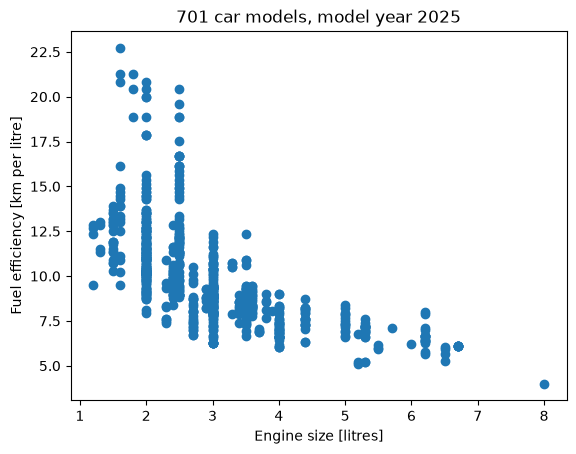

In [15]:
# a) Import the data as cars and print the first rows
cars = pd.read_csv('../00_Data/car_fuel_consumption_2025.csv', sep=',')
print(cars.shape)
print(cars[['make', 'model', 'engine_size', 'km_per_l']].head())

# b) Scatter plot km_per_l vs. engine_size
plt.scatter(cars['engine_size'], cars['km_per_l'])
plt.xlabel('Engine size [litres]')
plt.ylabel('Fuel efficiency [km per litre]')
plt.title('701 car models, model year 2025')
plt.show()

**Solution:**

The relationship is **not linear**: cars with small engines (up to 1.6 litres) reach on average about 13 km/l, the
efficiency drops quickly up to about 3 litres (≈ 10.6 km/l on average for 1.6–3 litres) and then flattens out (≈ 6.3 km/l
for 6–8 litres). A straight line cannot capture this curve (bias); a curved model (e.g. a polynomial) should fit better.

For the same engine size the efficiency still varies a lot – for 2-litre engines between about 8 and 21 km/l. The most
efficient cars are hybrids (e.g. Kia Niro, Toyota Corolla Hybrid, Toyota Prius). This is noise from the point of view of
a model that only knows the engine size.

## Exercise 3: Hold-out split and polynomial models

We describe the fuel efficiency as a polynomial of the engine size

$$\hat y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_d x^d .$$

This is still a *linear* regression (linear in the parameters $\beta$). The **degree $d$** controls the model complexity.
The helper function `make_poly_model(degree)` below builds such a model (the features are standardised for numerical
stability).

a) Split the table `cars` into a training set `train` (80 %) and a test set `test` (20 %) with
`random_state=42`.

b) Fit a polynomial of degree 1 (= simple linear regression) on the training set and compute the RMSE on the training
and on the test set.

In [16]:
# Function: builds a model with x, x², ..., x^degree and a linear regression
def make_poly_model(degree):
    """Polynomial regression model of the given degree."""
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    )

In [17]:
# Exercise 3 a) Split the table into training and test cars (80/20)
train, test = train_test_split(cars, test_size=0.20, random_state=42)
print('Training cars:', len(train), ' Test cars:', len(test))

# Feature (engine size) and target (km per litre)
X_train = train[['engine_size']]
y_train = train['km_per_l']
X_test = test[['engine_size']]
y_test = test['km_per_l']

# b) Fit a polynomial of degree 1 and compute the train and test RMSE
model_1 = make_poly_model(1)
model_1.fit(X_train, y_train)

# Train and test RMSE
rmse_train = root_mean_squared_error(y_train, model_1.predict(X_train))
rmse_test = root_mean_squared_error(y_test, model_1.predict(X_test))
print('Train RMSE:', round(rmse_train, 2))
print('Test RMSE:', round(rmse_test, 2))

Training cars: 560  Test cars: 141
Train RMSE: 2.16
Test RMSE: 2.25


## Exercise 4: Under- and overfitting with a small training sample

Overfitting is most visible when there are only few training examples. Imagine the importer knew only **30 car models**.

a) Draw a random sample of 30 cars from the training set (`train.sample(30, random_state=13)`).

b) For each degree $d = 1, 2, \dots, 10$ fit `make_poly_model(d)` on the 30 cars and compute the RMSE on these 30
training cars and on the (full) test set. Plot both RMSE curves against the degree (use a logarithmic y-axis).

c) Plot the fitted curves for the degrees 1, 2 and 8 together with the 30 training cars.

d) Which degree underfits, which overfits, which fits well? Why does the training error keep decreasing?

    train RMSE  test RMSE
1         2.46       2.32
2         2.35       2.33
3         2.34       2.28
4         2.34       2.50
5         2.34       4.04
6         2.33      18.46
7         2.33      32.70
8         2.28     364.21
9         2.30     367.16
10        2.31     343.62


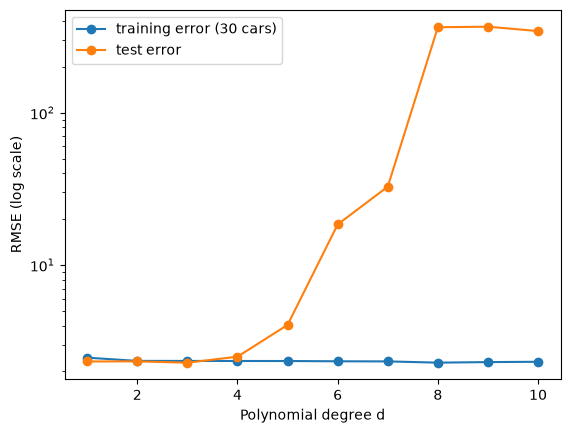

In [18]:
# a) Sample of 30 training cars
small = train.sample(30, random_state=13)
X_small = small[['engine_size']]
y_small = small['km_per_l']

# b) Train and test RMSE for degree 1..10
degrees = range(1, 11)
rmse_train = []
rmse_test = []
for d in degrees:
    model = make_poly_model(d)
    model.fit(X_small, y_small)
    rmse_train.append(root_mean_squared_error(y_small, model.predict(X_small)))
    rmse_test.append(root_mean_squared_error(y_test, model.predict(X_test)))

# Table of the train and test RMSE (one row per degree)
results = pd.DataFrame(
    {'train RMSE': rmse_train, 'test RMSE': rmse_test}, index=degrees
)
print(results.round(2))

# Figure showing the training and test error by polynomial degree
plt.plot(degrees, rmse_train, marker='o', label='training error (30 cars)')
plt.plot(degrees, rmse_test, marker='o', label='test error')
plt.yscale('log')
plt.xlabel('Polynomial degree d')
plt.ylabel('RMSE (log scale)')
plt.legend()
plt.show()

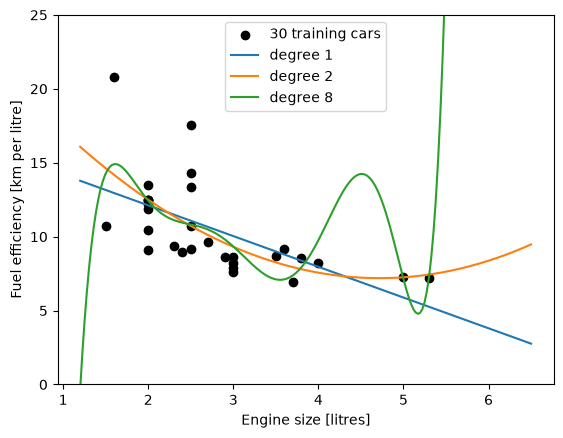

In [19]:
# c) Engine sizes from 1.2 to 6.5 litres (for smooth curves)
x_grid = pd.DataFrame({'engine_size': np.linspace(1.2, 6.5, 200)})

# Figure showing the 30 training cars and the fitted curves
plt.scatter(X_small, y_small, color='black', label='30 training cars')
for d in [1, 2, 8]:
    model = make_poly_model(d)
    model.fit(X_small, y_small)
    plt.plot(x_grid, model.predict(x_grid), label='degree ' + str(d))
plt.ylim(0, 25)
plt.xlabel('Engine size [litres]')
plt.ylabel('Fuel efficiency [km per litre]')
plt.legend()
plt.show()

**Solution:**

- **Degree 1 underfits slightly**: the straight line cannot follow the flattening curve and has the highest training
  error (2.46 km/l). With only 30 cars its test error (2.32) is about as large as the one of degrees 2 and 3.
- **Degree 2–3 fit well**: they follow the curve and have the lowest test error (≈ 2.3 km/l).
- **High degrees overfit**: the curve wiggles through the 30 training cars, the training error keeps decreasing, but the
  test error explodes from degree 5 on – up to ≈ 364 km/l for degree 8. The curve shoots up or down between and beyond
  the training cars.

The training error can (up to numerical rounding) only decrease with the degree, because a polynomial of degree $d+1$
contains the polynomial of degree $d$ as a special case ($\beta_{d+1}=0$). The training error is therefore an
*optimistically biased* estimate of the error on new data.

## Exercise 5: Choose the degree with 5-fold cross-validation

In practice we must not look at the test set to choose the degree. Instead we use k-fold cross-validation **on the
training data only**.

a) For $d = 1, \dots, 10$ compute the 5-fold CV RMSE on the **30 training cars**
(use `cross_val_score(..., scoring='neg_root_mean_squared_error', cv=KFold(5, shuffle=True, random_state=42))`;
note the minus sign). Which degree does CV select?

b) Repeat a) with the **full training set**. Which degree is selected now and how large is the difference between
degree 2 and the selected degree?

c) Fit the selected model on the full training set and evaluate it **once** on the test set.

d) Why does overfitting become much less severe with more data?

    CV (30 cars)  CV (all cars)
1          2.441          2.146
2          2.387          2.061
3          2.528          2.064
4          2.852          2.084
5          5.405          2.044
6          7.644          2.035
7          9.361          2.205
8         11.765          2.480
9         52.415          6.117
10        68.095          5.850


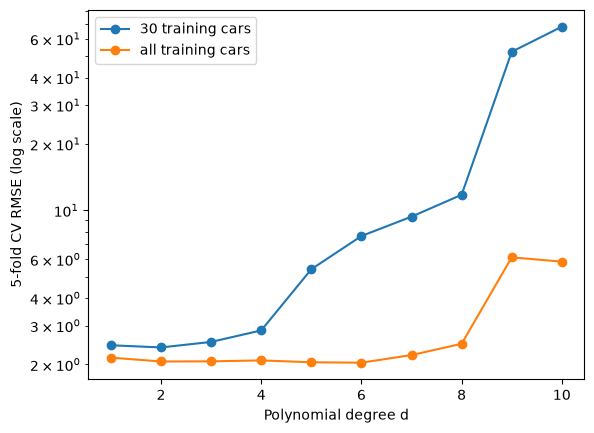

In [20]:
# Exercise 5: 5-fold cross-validation (on the training data only)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# a) and b) CV RMSE by degree for 30 cars and for all training cars
degrees_cv = range(1, 11)
cv_small = []
cv_full = []
for d in degrees_cv:
    scores = cross_val_score(
        make_poly_model(d),
        X_small,
        y_small,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )
    cv_small.append(-scores.mean())  # scikit-learn returns negative RMSE
    scores = cross_val_score(
        make_poly_model(d),
        X_train,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )
    cv_full.append(-scores.mean())

# Table of the CV RMSE (one row per degree)
results_cv = pd.DataFrame(
    {'CV (30 cars)': cv_small, 'CV (all cars)': cv_full}, index=degrees_cv
)
print(results_cv.round(3))

# Figure showing the CV RMSE by degree for both training sets
plt.plot(degrees_cv, cv_small, marker='o', label='30 training cars')
plt.plot(degrees_cv, cv_full, marker='o', label='all training cars')
plt.yscale('log')
plt.xlabel('Polynomial degree d')
plt.ylabel('5-fold CV RMSE (log scale)')
plt.legend()
plt.show()

In [21]:
# c) Fit the selected model on the full training set,
#    evaluate once on the test set

# Degree with the smallest CV RMSE on all training cars
best_degree = degrees_cv[np.argmin(cv_full)]
print('Selected degree:', best_degree)

# Fit it on all training cars and evaluate it once on the test set
final_model = make_poly_model(best_degree)
final_model.fit(X_train, y_train)
rmse_final = root_mean_squared_error(y_test, final_model.predict(X_test))
print('Test RMSE:', round(rmse_final, 3))

Selected degree: 6
Test RMSE: 2.141


**Solution:**

a) With only 30 cars, CV selects **degree 2** and the CV error explodes for high degrees (≈ 68 km/l for degree 10). CV
detects overfitting **without** using the test set.

b) With the full training set (560 cars) the CV curve is almost flat from degree 2 to degree 6 (≈ 2.04–2.06 km/l). CV
formally selects degree 6, but the difference to degree 2 is only about 1 % – in such a case one usually prefers the
**simpler** model. With many observations, the extra parameters of a flexible model are pinned down by the data – the
**variance** of the fit shrinks. Overfitting is always a question of model complexity *relative to the amount of data*.
(For degrees 9 and 10 the CV error rises again, because there are only few cars with very large engines.)

c) The selected model reaches a test RMSE of about 2.1 km/l.

d) The remaining error of about 2 km/l is mostly **noise from the perspective of this model** (hybrid drive, vehicle
class, transmission, …). It can only be reduced by adding further features, not by a more complex function of the
engine size.

## Exercise 6: Visualise bias and variance

Bias and variance describe what happens if we **repeat** the whole training on *other* samples of the same size.

a) Draw 50 different random samples of 30 cars from the training set (`random_state=0, 1, ..., 49`). For each sample
fit a polynomial of degree 1, 2 and 10. Plot the 50 fitted curves per degree (use `ylim(0, 25)`).

b) For each degree, compute the mean and the standard deviation of the 50 predictions for a car with a small engine
(**1.5 litres**). The cars in the data with an engine of at most 1.6 litres reach on average 13.0 km/l. What do you
observe? Relate your observations to bias and variance.

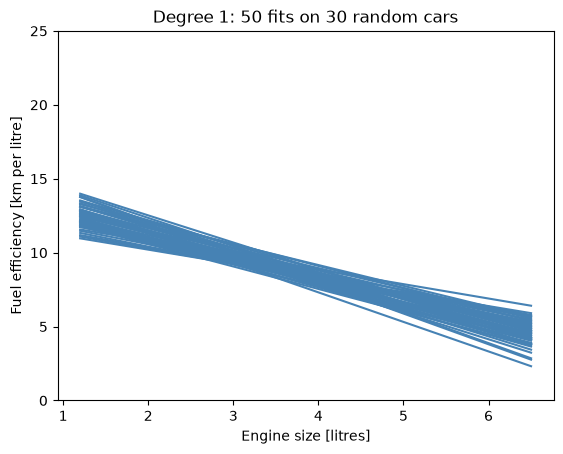

1.5 litres: mean = 12.03   standard deviation = 0.67


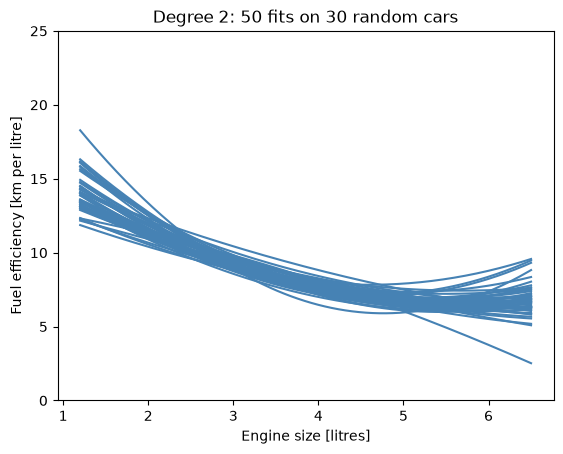

1.5 litres: mean = 13.07   standard deviation = 0.99


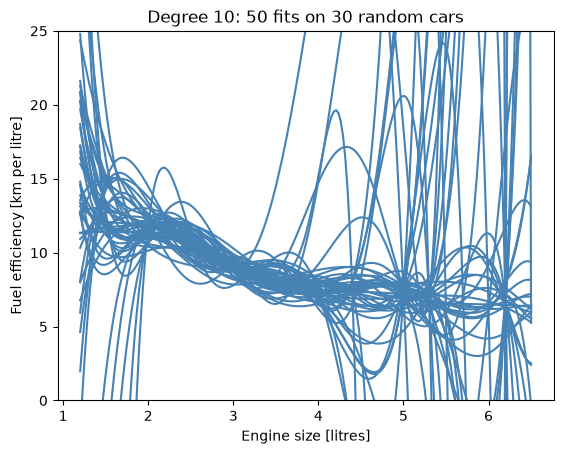

1.5 litres: mean = 8.03   standard deviation = 19.52


In [22]:
# Exercise 6: engine sizes for the curves and a car with 1.5 litres
x_grid = pd.DataFrame({'engine_size': np.linspace(1.2, 6.5, 200)})
car_15 = pd.DataFrame({'engine_size': [1.5]})

# a) and b) For each degree: 50 fits on random samples of 30 cars
for d in [1, 2, 10]:
    pred_15 = []
    for seed in range(50):
        sample = train.sample(30, random_state=seed)
        model = make_poly_model(d)
        model.fit(sample[['engine_size']], sample['km_per_l'])
        plt.plot(x_grid, model.predict(x_grid), color='steelblue')
        pred_15.append(model.predict(car_15)[0])

    # Figure showing the 50 fitted curves of this degree
    plt.ylim(0, 25)
    plt.title('Degree ' + str(d) + ': 50 fits on 30 random cars')
    plt.xlabel('Engine size [litres]')
    plt.ylabel('Fuel efficiency [km per litre]')
    plt.show()

    # Mean and standard deviation of the 50 predictions for 1.5 litres
    print(
        '1.5 litres: mean =',
        round(np.mean(pred_15), 2),
        '  standard deviation =',
        round(np.std(pred_15), 2),
    )

**Solution:**

- **Degree 1:** the 50 lines are similar to each other (standard deviation of the prediction for 1.5 litres ≈ 0.7), but
  they all miss the curve in the same way: for small engines they predict on average only 12.0 km/l instead of about
  13.0 km/l → high **bias**.
- **Degree 2:** the curves follow the shape of the data; the mean prediction (≈ 13.1 km/l) is close to the true average
  and the predictions vary only moderately (≈ 1.0) – a good compromise.
- **Degree 10:** the curves differ wildly from sample to sample, especially for small and large engines (high
  **variance**): the standard deviation of the prediction for 1.5 litres is ≈ 19.5 km/l.

This is exactly the bias–variance trade-off: a simple model is *stable but systematically wrong*, a very flexible model
is *right on average but unstable*. The best test error is achieved in between.

## Exercise 7: More covariates instead of a more complex curve

Exercise 5 showed that a higher polynomial degree hardly reduces the error. The remaining error is "noise" only from
the point of view of a model that knows nothing but the engine size. Other properties of the car explain part of it.

a) Fit a linear regression with a polynomial of degree 2 in `engine_size` **plus** the covariates `cylinders`,
`vehicle_class`, `transmission_type` and `fuel_type` (the code for the features is given).
Use `make_pipeline(StandardScaler(), LinearRegression())`.

b) Compare its 5-fold CV RMSE and test RMSE with the polynomial of degree 2 without covariates.

c) What does this tell you about bias, variance and the noise term?

In [23]:
# Exercise 7 a) Engine size, its square and the covariates
# (vehicle class, transmission type and fuel type as dummy variables)
features = [
    'engine_size',
    'cylinders',
    'vehicle_class',
    'transmission_type',
    'fuel_type',
]
X_cov = pd.get_dummies(
    cars[features],
    columns=['vehicle_class', 'transmission_type', 'fuel_type'],
    drop_first=True,
    dtype=int,
)
X_cov['engine_size_2'] = X_cov['engine_size'] ** 2

# Same random_state as in Exercise 3 -> the same training and test cars
X_cov_train, X_cov_test = train_test_split(
    X_cov, test_size=0.20, random_state=42
)

# Fit the linear regression with all features
# (standardised, as in make_poly_model)
model_cov = make_pipeline(StandardScaler(), LinearRegression())
model_cov.fit(X_cov_train, y_train)

# b) CV RMSE and test RMSE; compare with degree 2 without covariates
scores = cross_val_score(
    model_cov,
    X_cov_train,
    y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error',
)
rmse_cov = root_mean_squared_error(y_test, model_cov.predict(X_cov_test))
print(
    'Engine size + covariates: CV RMSE =',
    round(-scores.mean(), 3),
    '  test RMSE =',
    round(rmse_cov, 3),
)

# Comparison: degree 2 without covariates (CV RMSE from Exercise 5)
model_2 = make_poly_model(2)
model_2.fit(X_train, y_train)
rmse_2 = root_mean_squared_error(y_test, model_2.predict(X_test))
print(
    'Engine size only:         CV RMSE =',
    round(cv_full[1], 3),
    '  test RMSE =',
    round(rmse_2, 3),
)

Engine size + covariates: CV RMSE = 1.573   test RMSE = 1.764
Engine size only:         CV RMSE = 2.061   test RMSE = 2.158


**Solution:**

b)
| model | CV RMSE | test RMSE |
|:---|:---|:---|
| degree 2 (engine size only) | ≈ 2.06 km/l | ≈ 2.16 km/l |
| degree 2 + cylinders, vehicle class, transmission, fuel type | ≈ 1.57 km/l | ≈ 1.76 km/l |

With the additional covariates the error drops by about a quarter – a much larger gain than any change of the
polynomial degree in Exercises 4 and 5. The transmission type helps most: cars with a continuously variable transmission
(often hybrids) reach on average 14.0 km/l, cars with other transmissions 8.4–10.4 km/l. Pickups and large SUVs are
less efficient than compact cars with the same engine size.

c) The "noise" $\sigma^2$ in the bias–variance decomposition is always noise **relative to the available features**.
A more flexible function of the engine size can only trade bias against variance; it cannot explain why a compact hybrid
car with a 2-litre engine is much more efficient than a pickup with the same engine size. New, informative covariates
reduce the part of the error that looked like irreducible noise. They add only about 20 parameters, so the variance
increases only a little (CV and test errors are similar).

## Exercise 8: Reflection

a) A colleague chooses the polynomial degree by trying all degrees and picking the one with the smallest **test** error.
What is the problem?

b) Why is k-fold cross-validation usually preferred over a single validation split when the data set is small?

c) Name two ways to reduce the variance of a model and one way to reduce its bias.

**Solution:**

a) The test set is then used for model selection; the reported test error is the *minimum* over many models and
therefore optimistically biased. The test set no longer measures performance on truly unseen data. Hyperparameters must
be chosen with a validation set or cross-validation on the training data.

b) With a single split, the result depends strongly on which few observations end up in the validation set. k-fold CV
uses every observation once for validation and averages over $k$ estimates, which gives a more stable estimate and uses
the data more efficiently.

c) Lower variance: collect more training data, use a simpler model (lower degree), regularisation/pruning, or averaging
many models (bagging, random forest). Lower bias: use a more flexible model (e.g. higher degree, trees) or add
informative features (e.g. vehicle class, transmission type).

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [24]:
# Show operating system, date/time and Python version
print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-02 15:45:13
Python Version: 3.11.16
-----------------------------------
